Restarted Data370_25au_p312 (Python 3.12.11)


 # MNIST Digits dataset
 ## Homework 2
 ### Leo Lu
 Let us familiarize ourselves with this well-known MNIST dataset on digits. It is decent large,
 with 60k observations. Each oberservatin is a 28x28 pixel gray scale image (digitized),
 and 256 gray levels. The first column of the dataset (csv) is the target y value (0 to 9).
 The remaining 784 columns are the gray values for each pixel for each observation.

 ## STEP 1: Read in the dataset

In [ ]:
import pandas as pd
import os
import warnings, numpy as np
from torch import lt
warnings.filterwarnings("ignore", category=RuntimeWarning)        # 隐藏 RuntimeWarning
np.seterr(divide="ignore", invalid="ignore", over="ignore")       # 静音 numpy 的报错通道


headers = ['y'] + [f'x{i}' for i in range(784)]

filepath = os.path.join('bigdata', 'mnist_train.csv')
dfdigits = pd.read_csv(filepath, names=headers)

df = pd.read_csv(filepath)

print("DataFrame shape (rows, columns):", dfdigits.shape)
print("\nFirst 5 rows of the data:")
print(dfdigits.head())

DataFrame shape (rows, columns): (60000, 785)

First 5 rows of the data:
   y  x0  x1  x2  x3  x4  x5  x6  x7  x8  ...  x774  x775  x776  x777  x778  \
0  5   0   0   0   0   0   0   0   0   0  ...     0     0     0     0     0   
1  0   0   0   0   0   0   0   0   0   0  ...     0     0     0     0     0   
2  4   0   0   0   0   0   0   0   0   0  ...     0     0     0     0     0   
3  1   0   0   0   0   0   0   0   0   0  ...     0     0     0     0     0   
4  9   0   0   0   0   0   0   0   0   0  ...     0     0     0     0     0   

   x779  x780  x781  x782  x783  
0     0     0     0     0     0  
1     0     0     0     0     0  
2     0     0     0     0     0  
3     0     0     0     0     0  
4     0     0     0     0     0  

[5 rows x 785 columns]


 ## STEP 2 (optional): Preparing the data
 If using all 60k observations takes forever in your
 work, you can take some smaller random sample to try.
 As it turns out, the rows of data are already randomized.
 If you just take the first 10k rows or 8k, it might work okay.

 If we were to do some modeling (classifiers or regressions). we
 would need to prepare for train-test split. Say 4:1. But for now
 we'll just do clustering and PCA.

 from sklearn.model_selection import train_test_split
 from sklearn.model_selection import train_test_split
 X_train, X_test, y_train, y_test= train_test_split(df.iloc[0:,1:], df["x000"], test_size=0.2, stratify=df["x000"],random_state=1)

 If the latter modeling part does not run, check the X_train, X_test has the
 right object type. Use the 8x8 pixel sample in class as a guide.


 ## STEP 3: View some samples
 Plot the first and the last row of your train set, and see the image as we
 did in class. Make sure the format is a 28x28 array for the plot to work.

 What do they look like?
 https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html

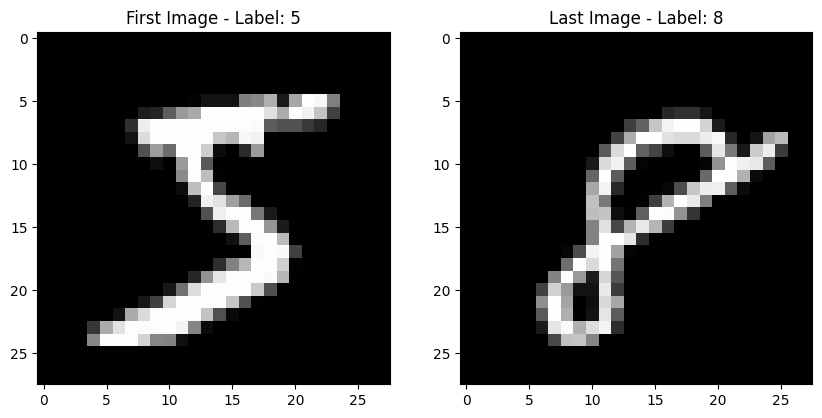

In [ ]:
import matplotlib.pyplot as plt 
y = dfdigits['y']
X = dfdigits.drop('y', axis=1)

first_pixels = X.iloc[0].values
last_pixels = X.iloc[-1].values

first_img = first_pixels.reshape(28, 28)
last_img = last_pixels.reshape(28, 28)

fig, axes=plt.subplots(1,2, figsize=(10,5))
axes[0].imshow(first_img, cmap='gray')
axes[0].set_title(f"First Image - Label: {y.iloc[0]}")

axes[1].imshow(last_img, cmap='gray')
axes[1].set_title(f"Last Image - Label: {y.iloc[-1]}")
plt.show()

 ## STEP 4: Perform PCA and Kmeans on this dataset.
 Explain your work and your findings.
 For Kmeans, what number of clusters did you end up find it most
 reasonble? How did you come up with that conclusion?
 What does that mean here?
 This is an open ended question. Please show your inquisitiveness
 on an new exposure.

 ### Part A: Perform PCA

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_scaled)

print("\nPCA complete!")
print(f"Original number of features: {X_scaled.shape[1]}")
print(f"Reduced number of features after PCA: {X_pca.shape[1]}")

reduction_percentage = (1 - (X_pca.shape[1] / X_scaled.shape[1])) * 100
print(f"Percentage reduction in features: {reduction_percentage:.2f}%")

variance_explained = sum(pca.explained_variance_ratio_) * 100
print(f"Variance explained: {variance_explained:.2f}%")


PCA complete!
Original number of features: 784
Reduced number of features after PCA: 331
Percentage reduction in features: 57.78%
Variance explained: 95.03%


 #### Creating a new DataFrame with PCA results (scores)

In [ ]:
pca_cols = [f'PC{i+1}' for i in range(X_pca.shape[1])]
pca_df = pd.DataFrame(X_pca, columns=pca_cols)

print("\nExplained variance ratio (first 10):")
print(pca.explained_variance_ratio_[:10])

print("\nSingular values (first 10):")
print(pca.singular_values_[:10])

print("\nComponents (eigenvectors) shape:", pca.components_.shape)
print("\nTransformed Data (PCA Scores) — head:")
print(pca_df.head())


Explained variance ratio (first 10):
[0.05646717 0.04078272 0.0373938  0.02885115 0.02521109 0.0219427
 0.01923344 0.01745799 0.01535092 0.0140172 ]

Singular values (first 10):
[1558.59475775 1324.56506425 1268.33806904 1114.08096949 1041.4321537
  971.58372712  909.62781125  866.6272717   812.64796157  776.54347762]

Components (eigenvectors) shape: (331, 784)

Transformed Data (PCA Scores) — head:
        PC1       PC2       PC3       PC4       PC5       PC6        PC7  \
0 -0.922159 -4.814790  0.067560  8.051329  0.985347  0.951616  -0.336139   
1  8.708977 -7.754403 -3.447910  1.668321 -0.834795 -5.144664   0.272279   
2  2.328389  9.431338 -6.184114 -1.725066 -4.092456  2.291390 -18.691539   
3 -6.582173 -3.746318  3.690851  0.461041 -5.627325  3.461544  -1.561415   
4 -5.183251  3.133297 -6.277947 -1.459654  1.608842 -0.612565   0.580065   

        PC8       PC9      PC10  ...     PC322     PC323     PC324     PC325  \
0  1.393473 -1.052314  2.324207  ... -0.599098  0.774019  

 #### Plotting the results of PCA 1 & 2

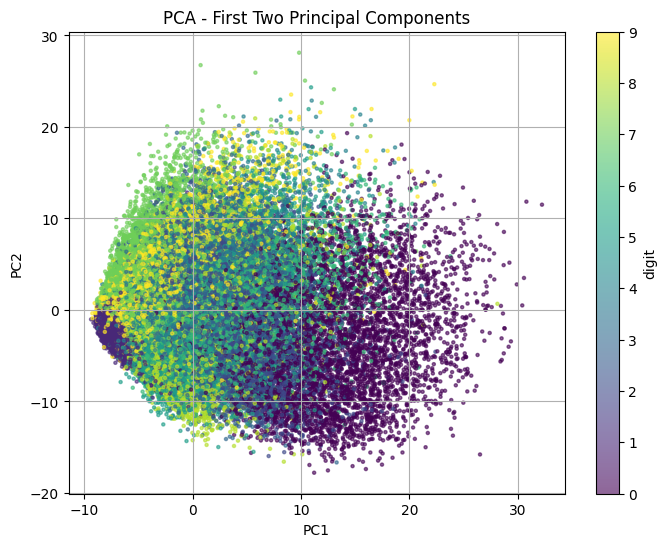

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=y, s=5, alpha=0.6)
plt.title('PCA - First Two Principal Components')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(label='digit')
plt.grid(True)
plt.show()

 #### Correlation and Covariance Matrix Heatmaps (PC1–PC4)


cor_matrix (PC1–PC4):
               PC1           PC2           PC3           PC4
PC1  1.000000e+00  8.788125e-15  6.299194e-16 -3.279242e-15
PC2  8.788125e-15  1.000000e+00 -2.357551e-15 -6.636036e-16
PC3  6.299194e-16 -2.357551e-15  1.000000e+00  4.862521e-15
PC4 -3.279242e-15 -6.636036e-16  4.862521e-15  1.000000e+00

cov_matrix (PC1–PC4):
               PC1           PC2           PC3           PC4
PC1  4.048764e+01  3.019289e-13  1.824361e-14 -9.490214e-14
PC2  3.019289e-13  2.924170e+01 -6.712633e-14 -1.796566e-14
PC3  1.824361e-14 -6.712633e-14  2.681180e+01  1.145298e-13
PC4 -9.490214e-14 -1.796566e-14  1.145298e-13  2.068662e+01


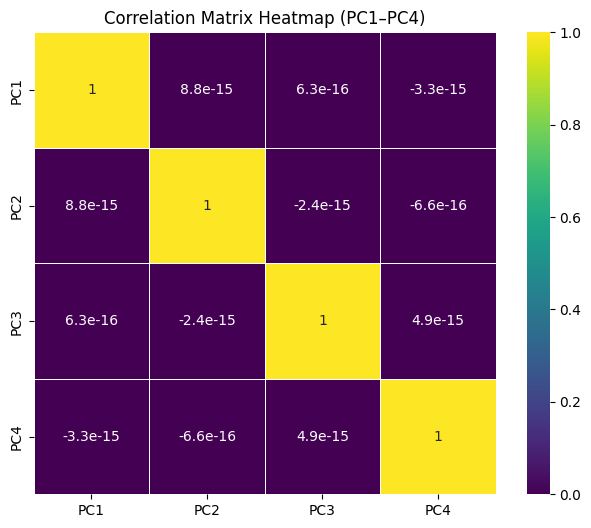

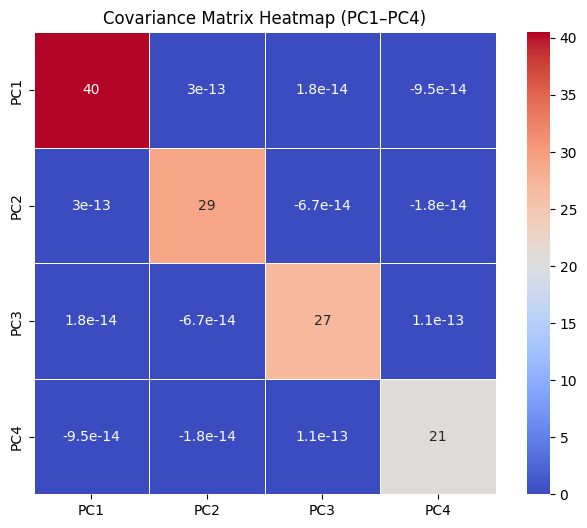

In [ ]:
import seaborn as sns
k = min(4, pca_df.shape[1])
pc_small = pca_df.iloc[:, :k]

cor_matrix = pc_small.corr()
cov_matrix = pc_small.cov()

print("\ncor_matrix (PC1–PC4):\n", cor_matrix)
print("\ncov_matrix (PC1–PC4):\n", cov_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(cor_matrix, annot=True, cmap='viridis', linewidths=.5, square=True)
plt.title('Correlation Matrix Heatmap (PC1–PC4)')
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(cov_matrix, annot=True, cmap='coolwarm', linewidths=.5, square=True)
plt.title('Covariance Matrix Heatmap (PC1–PC4)')
plt.show()

 #### Key Findings:
 - I applied PCA to the MNIST dataset and reduced the number of features from 784 to 331 while retaining 95% of the variance.
 - We can see that the first few principal components capture a significant portion of the variance, indicating that a small subset of features is sufficient for representing the data.
 - The first two principal components (PC1 and PC2) capture the most variance and can be visualized effectively.
 - The scatter plot of PC1 vs. PC2 shows some clustering of digits, suggesting that PCA helps in separating different digit classes.
 - However, from the scatter plot, we can see that some digits overlap, indicating we may need more components to achieve better separation.
 - The correlation heatmaps are diagonal, indicating that the principal components are uncorrelated, which is a key property of PCA.
 - The covariance heatmap shows that the principal components have varying degrees of variance, and is decreasing as we move to higher components.

 ### Part B: Perform KMeans Clustering
 #### Elbow Method to Determine Optimal k

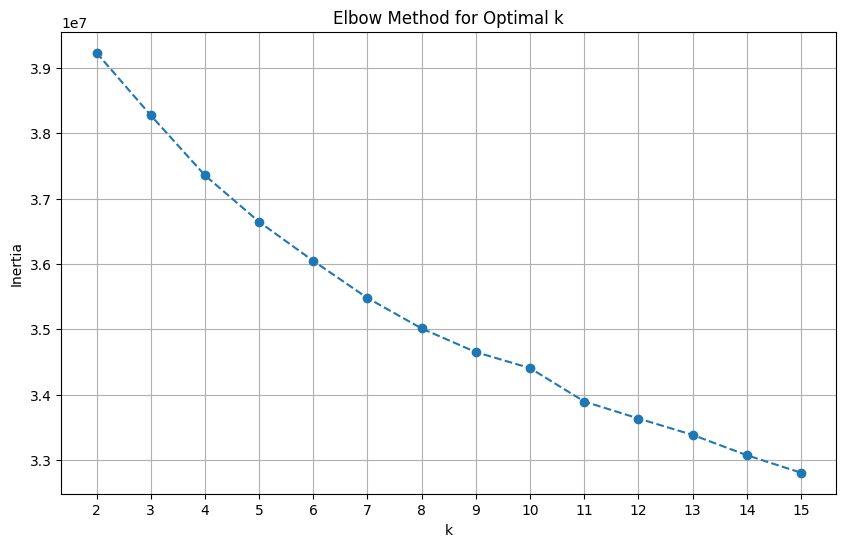

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

possible_k = range(2, 16)
inertias = []

for k in possible_k:
    m = KMeans(n_clusters=k, random_state=42, n_init='auto')
    m.fit(X_pca)
    inertias.append(m.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(possible_k, inertias, marker='o', linestyle='--')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(possible_k)
plt.grid(True)
plt.show()

 #### KMeans with k=10

In [ ]:
kmeans = KMeans(n_clusters=10, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X_pca)

print("\nKMeans clustering complete!")
print(f"Cluster centers shape: {kmeans.cluster_centers_.shape}")
print(f"First 20 cluster labels: {clusters[:20]}")


KMeans clustering complete!
Cluster centers shape: (10, 331)
First 20 cluster labels: [3 1 6 8 6 3 2 3 2 3 4 8 5 0 2 9 7 8 0 9]


 #### Plotting KMeans Clusters

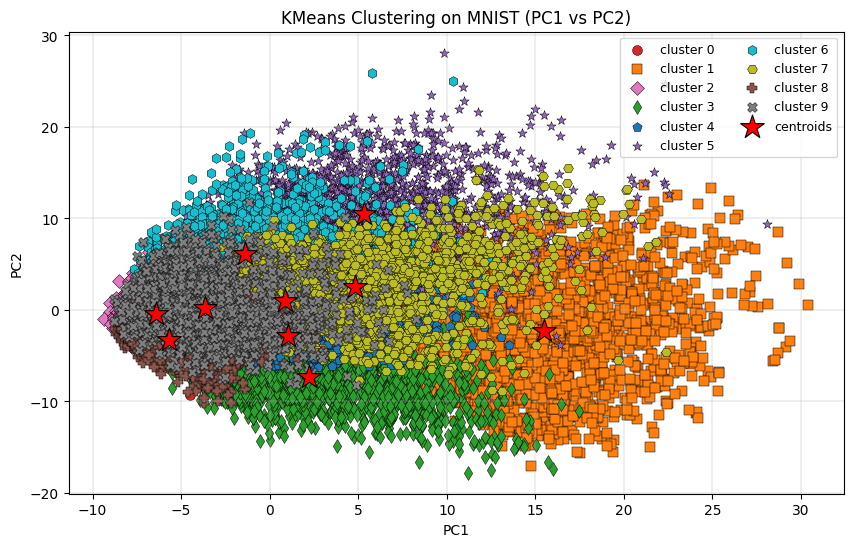

In [ ]:
index1 = 0
index2 = 1
s_per_c = 2000

colors  = ['tab:red','tab:orange','tab:pink','tab:green','tab:blue',
           'tab:purple','tab:cyan','tab:olive','tab:brown','tab:gray']
markers = ['o','s','D','d','p','*','h','H','P','X']

plt.figure(figsize=(10, 6))

for c in range(10):
    idx_all = np.where(clusters == c)[0]
    idx = np.random.choice(idx_all, s_per_c, replace=False) if len(idx_all) > s_per_c else idx_all

    plt.scatter(
        X_pca[idx, index1], X_pca[idx, index2],
        s=50,
        c=colors[c], marker=markers[c],
        edgecolor='black', linewidths=0.35,
        alpha=1.0,
        label=f'cluster {c}'
    )

centers_2d = kmeans.cluster_centers_[:, [index1, index2]]
plt.scatter(
    centers_2d[:, 0], centers_2d[:, 1],
    s=320, marker='*', c='red', edgecolor='black', linewidths=0.8,
    label='centroids', zorder=10
)

plt.legend(scatterpoints=1, ncol=2, fontsize=9)
plt.title('KMeans Clustering on MNIST (PC1 vs PC2)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.grid(True, linewidth=0.3)
plt.show()

 #### Key Findings:
 - Using the Elbow Method, we can see a noticeable drop in inertia around k=10, suggesting that 10 clusters is a reasonable choice.
 - Given the task context, k=10 is the best choice as it corresponds to the 10 digit classes (0-9) in the MNIST dataset.
 - Without knowing the decimal digits, we might still choose k around 10 based on the elbow plot.
 - The KMeans clustering results show distinct clusters in the PCA-reduced space
 - However, some clusters overlap, suggesting that while KMeans is effective, it may not perfectly separate all digit classes